In [20]:
import sys
import os
sys.path.append(os.path.abspath('../..'))


# from scan_engine.status_fields_config_24summ import STATUS_FIELDS_CONFIG
from status_fields_config_oct3v1_brws_250523 import STATUS_FIELDS_CONFIG

from utlis.scan_engine_utlis.scan_eng_big_utlis import log_folder_to_parquet_sep

if __name__ == "__main__":
    base_folder = '/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon' #"/hpc/group/tdunn/Bryan_Rigs/BigOpenField/Oct3V1" #"/hpc/group/tdunn/Bryan_Rigs/BigOpenField/24summ"  # Replace with your base folder
    # save_path = os.path.join(base_folder, 'paret')
    failed_paths_file = None #"/hpc/group/tdunn/Bryan_Rigs/BigOpenField/Oct3V1/sync_failed.txt" #'/hpc/group/tdunn/Bryan_Rigs/BigOpenField/Oct3V1/sync_failed_brws.txt'  # File containing failed paths

    force_rescan_rec_files = [
        # ('2023-10-01', '001'),
        # ('2023-10-02', '002'),
        # Add more as needed
    ]
    rescan_threshold_days = 0.001 # 7 days, but guess if i mess up i can just change it to automatically rescan all, smile... #0.1

    log_folder_to_parquet_sep(base_folder, failed_paths_file, STATUS_FIELDS_CONFIG,
                              force_rescan_rec_files=force_rescan_rec_files,
                              rescan_threshold_days=rescan_threshold_days)


No new or modified folders to scan.


In [21]:
sys.path.append(os.path.abspath('../..'))
from utlis.scan_engine_utlis.scan_engine_utlis import read_all_parquet_files
# base_folder = "/hpc/group/tdunn/Bryan_Rigs/BigOpenField/Oct3V1"
all_df = read_all_parquet_files(base_folder)

In [25]:
import pyarrow.compute as pc
from functools import reduce


table = all_df #combined_df
# Filter mir_generate_param == 0 and sync != 3
conditions = [
#    pc.equal(table['mir_generate_param'], '0'),
#    pc.equal(table['sync'], '1'),
   # pc.not_equal(table['sync'], '3'),
   pc.equal(table['com'], '1'),
#    pc.equal(table['com_vis'], '1'),
   # # pc.equal(table['v1'], '1'),
   pc.equal(table['dannce'], '0'),
   # pc.equal(table['dannce_vis'], '1'),
   pc.equal(table['social'], '0'),
   # pc.equal(table['mini_6cam_map'], '1'),
   # pc.equal(table['mini_rec_sync_com'], '1'),
   #mini_rec_sync
   # mini_6cam_map
]

filter_mask = reduce(pc.and_, conditions)



# Apply the filter and print the results
for_com = table.filter(filter_mask)

# Print each row of the filtered table
print(for_com.to_pandas())  # This will display the filtered data in a familiar pandas-like format


  mir_generate_param sync mini_6cam_map dropf_handle com com_vis social  \
0                  1    1             0            0   1       0      0   
1                  1    1             0            0   1       0      0   
2                  1    1             0            0   1       0      0   

  miniscope test after_oxytocin before_oxytocin dannce dannce_vis  \
0         1    0              0               0      0          0   
1         1    0              0               0      0          0   
2         1    0              0               0      0          0   

  mini_rec_sync               rec_file                   scan_time  \
0             0          20250407v1l23  2025-07-07T19:25:09.273870   
1             0    20250505v1l23r1pink  2025-07-07T19:25:09.131360   
2             0  20250506v1l23l1yellow  2025-07-07T19:25:09.263407   

                                            rec_path date_folder  \
0  /hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField...  2025_07_02   
1  /h

In [26]:
# Convert and flatten the ChunkedArray
experiment_paths = for_com["rec_path"].to_pylist()

# Print each path
for path in experiment_paths:
    # Each element is likely a list with one string, e.g., ['/some/path']
    print(path[0] if isinstance(path, list) else path)


/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_07_02/20250407v1l23
/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_07_02/20250505v1l23r1pink
/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_07_02/20250506v1l23l1yellow


In [16]:
# for_com=for_com_vis

from concurrent.futures import ThreadPoolExecutor
import os

import subprocess

def get_num_running_jobs(user):
    result = subprocess.run(
        ['squeue', '-u', user, '-h', '-t', 'R'],
        stdout=subprocess.PIPE,
        text=True
    )
    lines = result.stdout.strip().split('\n')
    # Filter out empty lines
    running_jobs = [line for line in lines if line]
    return len(running_jobs)



slurm_launch_file = '/hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict.py'

def check_expdir(expdir):
    if not os.path.exists(expdir):
        print(f"Skipping: Experiment directory {expdir} does not exist")
        return None  # Return None or skip processing this directory
    return expdir


# Function to create the full expdir path and print the command for dry-run
def run_command(base_path, date_folder, rec_file, dry_run=True):
    expdir_path = os.path.join(base_path, date_folder, rec_file)
    
    # Check if the experiment directory exists before running the command
    if check_expdir(expdir_path) is None:
        return  # Skip this execution if the directory does not exist
    
    # command = f"python {slurm_launch_file} --expdir {expdir_path} --predict_com"
    command = f"conda run -n sdannce python {slurm_launch_file} --expdir {expdir_path} --predict_com --allow_overwrite" #--allow_overwrite

    if dry_run:
        print(f"[DRY-RUN] Command: {command}")
    else:
        print(f"Executing command: {command}")
        os.system(command)


# Extract relevant data from the filtered PyArrow Table `for_com`
base_path = base_folder #"/hpc/group/tdunn/Bryan_Rigs/BigOpenField/24summ"  # Adjust this base path as needed
records = [
    {
        'date_folder': date_folder.as_py(),  # Convert to string using as_py()
        'rec_file': rec_file.as_py()         # Convert to string using as_py()
    }
    for date_folder, rec_file in zip(for_com['date_folder'], for_com['rec_file'])
]

# Run in parallel with dry-run enabled for testing
# max_concurrent_jobs = 6 # chosing how mnay gpu to take, let's say maybe 4??? or 5... we're not urgent so.... this actually would not work because submitting jobs takes a second... so whatever...
user = 'lq53'

dry_run = False #True  # Set to False to execute commands
with ThreadPoolExecutor() as executor: #max_workers=max_concurrent_jobs
    futures = [
        executor.submit(run_command, base_path, record['date_folder'], record['rec_file'], dry_run)
        for record in records
    ]
# for record in records:
#     while True:
#         num_jobs = get_num_running_jobs(user)
#         if num_jobs < max_concurrent_jobs:
#             # Submit the job
#             run_command(base_path, record['date_folder'], record['rec_file'], dry_run)
#             break
#         else:
#             # Wait before checking again
#             time.sleep(30)  # Wait for 30 seconds before retrying


# print("Dry-run test complete. Review the printed commands.")


Executing command: conda run -n sdannce python /hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict.py --expdir /hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_07_02/20250505v1l23r1pink --predict_com --allow_overwrite
Executing command: conda run -n sdannce python /hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict.py --expdir /hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_07_02/20250505v1l23r1pink_onlybehavior --predict_com --allow_overwrite
Specified a single expdir; running predictions ...
Running command:  cd /hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_07_02/20250505v1l23r1pink_onlybehavior
dannce predict com /hpc/group/tdunn/tqxli/sdannce_scripts/configs/com_mouse_config.yaml --com-predict-weights=/hpc/group/tdunn/tqxli/sdannce_scripts/weights/COM/checkpoint-epoch20.pth --com-predict-dir=COM/predict00 --max-num-samples 100000 --batch-size=1
Slurm out: /hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenF

In [17]:
# from concurrent.futures import ThreadPoolExecutor
# import os

# slurm_launch_file = '/hpc/group/tdunn/lq53/tianqing_pytorch_dannce/sdannce_scripts/slurm_launch_predict.py'

# def check_expdir(expdir):
#     if not os.path.exists(expdir):
#         print(f"Skipping: Experiment directory {expdir} does not exist")
#         return None  # Return None or skip processing this directory
#     return expdir


# # Function to create the full expdir path and print the command for dry-run
# def run_command(base_path, date_folder, rec_file, dry_run=True):
#     expdir_path = os.path.join(base_path, date_folder, rec_file)
    
#     # Check if the experiment directory exists before running the command
#     if check_expdir(expdir_path) is None:
#         return  # Skip this execution if the directory does not exist
    
#     # command = f"python {slurm_launch_file} --expdir {expdir_path} --predict_com"
#     command = f"conda run -n sdannce python {slurm_launch_file} --expdir {expdir_path} --predict_com"

#     if dry_run:
#         print(f"[DRY-RUN] Command: {command}")
#     else:
#         print(f"Executing command: {command}")
#         os.system(command)


# # Extract relevant data from the filtered PyArrow Table `for_com`
# base_path = base_folder #"/hpc/group/tdunn/Bryan_Rigs/BigOpenField/24summ"  # Adjust this base path as needed
# records = [
#     {
#         'date_folder': date_folder.as_py(),  # Convert to string using as_py()
#         'rec_file': rec_file.as_py()         # Convert to string using as_py()
#     }
#     for date_folder, rec_file in zip(for_dh['date_folder'], for_dh['rec_file'])
# ]

# # Run in parallel with dry-run enabled for testing
# max_concurrent_jobs = 2 # chosing how mnay gpu to take, let's say maybe 4??? or 5... we're not urgent so...

# dry_run = False #True  # Set to False to execute commands
# # parallelly submission of jobs is just stupid....
# # with ThreadPoolExecutor(max_workers=max_concurrent_jobs) as executor:
# #     futures = [
# #         executor.submit(run_command, base_path, record['date_folder'], record['rec_file'], dry_run)
# #         for record in records
# #     ]


# # print("Dry-run test complete. Review the printed commands.")

Executing command: conda run -n sdannce python /hpc/group/tdunn/lq53/tianqing_pytorch_dannce/sdannce_scripts/slurm_launch_predict.py --expdir /hpc/group/tdunn/Bryan_Rigs/BigOpenField/Oct3V1/2024_09_18/20240707-PMC-r1 --predict_com
Executing command: conda run -n sdannce python /hpc/group/tdunn/lq53/tianqing_pytorch_dannce/sdannce_scripts/slurm_launch_predict.py --expdir /hpc/group/tdunn/Bryan_Rigs/BigOpenField/Oct3V1/2024_09_18/20240819-V1-r2 --predict_com
Executing command: conda run -n sdannce python /hpc/group/tdunn/lq53/tianqing_pytorch_dannce/sdannce_scripts/slurm_launch_predict.py --expdir /hpc/group/tdunn/Bryan_Rigs/BigOpenField/Oct3V1/2024_09_18/20240819_V1_r1 --predict_com
Executing command: conda run -n sdannce python /hpc/group/tdunn/lq53/tianqing_pytorch_dannce/sdannce_scripts/slurm_launch_predict.py --expdir /hpc/group/tdunn/Bryan_Rigs/BigOpenField/Oct3V1/2024_09_18/20240819_V1_r1_2 --predict_com
Executing command: conda run -n sdannce python /hpc/group/tdunn/lq53/tianqing

In [12]:
import pyarrow.compute as pc
table = all_df  # combined_df

# Filter dropf_handle == 1, com != 1, and social != 1
# filter_mask = pc.and_(
#     # pc.equal(table['dropf_handle'], '1'),
#     pc.not_equal(table['com'], '1'),
#     pc.not_equal(table['social'], '1')
# )

filter_mask = pc.and_(
    # pc.and_(
        # pc.not_equal(table['date_folder'], '2024_11_06'),
        
        # pc.and_(
        #     pc.not_equal(table['date_folder'], '2024_11_06'),
        #     # pc.and_(
        #     #     pc.not_equal(table['date_folder'], '2024_11_06'),
        #     #     pc.not_equal(table['date_folder'], '2024_09_18')
        #     # ),
        #     pc.not_equal(table['date_folder'], '2024_11_07')
        # ),
    pc.equal(table['com'], '1'),
    # ),
    # pc.not_equal(table['social'], '1')
    pc.and_(
        pc.not_equal(table['social'], '1'),
        pc.equal(table['date_folder'], '2024_11_13')
    )
)

# Apply the filter and print the results
for_com_vis = table.filter(pc.equal(table['com'], '1'))

# Print each row of the filtered table
print(for_com_vis.to_pandas())  # Display the filtered data in a familiar pandas-like format


  mir_generate_param sync mini_6cam_map dropf_handle com social miniscope  \
0                  1    1             0            0   1      1         0   
1                  1    1             0            0   1      1         0   

  test dannce mini_rec_sync                   rec_file  \
0    0      0             0  1shank3KOM_boxedshank3KOF   
1    0      0             0  1shank3WTM_boxedshank3WTF   

                    scan_time date_folder                  calib_files  
0  2025-05-05T15:05:44.924567  2025_05_02  [calib_before, calib_after]  
1  2025-05-05T15:05:44.920008  2025_05_02  [calib_before, calib_after]  


In [ ]:
# from utlis.vis_valid_utlis.com_trag_updated import plot_com_all

# plot_com_all() #com_folder_name='COM/predict00', perform_jump_indices=True, perform_video_generation=False, perform_generate_com_video=False

In [ ]:
from utlis.vis_valid_utlis.com_trag_updated import plot_com_all

# Assume base_folder is defined elsewhere in your script
# base_folder = '/path/to/your/base/folder'

for_com_vis = for_com

records = [
    {
        'date_folder': date_folder.as_py(),  # Convert to string using as_py()
        'rec_file': rec_file.as_py()         # Convert to string using as_py()
    }
    for date_folder, rec_file in zip(for_com_vis['date_folder'], for_com_vis['rec_file'])
]

# Iterate through the records and process each one sequentially
for record in records:
    base_path = f"{base_folder}/{record['date_folder']}/{record['rec_file']}"
    print(base_path)
    plot_com_all(base_path,perform_jump_indices=True) #com_folder_name='COM/predict00', perform_jump_indices=True, perform_video_generation=False, perform_generate_com_video=False


In [7]:
import pyarrow.compute as pc
table = all_df  # combined_df

# Filter dropf_handle == 1, com != 1, and social != 1
filter_mask = pc.and_(
    # pc.equal(table['dropf_handle'], '1'),
    pc.equal(table['com'], '1'),
    pc.not_equal(table['dannce'], '1'),
    # pc.not_equal(table['social'], '1')
    # pc.and_(
    #     pc.not_equal(table['dannce'], '1'),
    #     pc.not_equal(table['test'], '1'),
    #     # pc.equal(table['sync'], '1')
    # )
)

# filter_mask = pc.and_(
#     # pc.and_(
#         # pc.not_equal(table['date_folder'], '2024_11_06'),
        
#         # pc.and_(
#         #     pc.not_equal(table['date_folder'], '2024_11_06'),
#         #     # pc.and_(
#         #     #     pc.not_equal(table['date_folder'], '2024_11_06'),
#         #     #     pc.not_equal(table['date_folder'], '2024_09_18')
#         #     # ),
#         #     pc.not_equal(table['date_folder'], '2024_11_07')
#         # ),
#     pc.equal(table['com'], '1'),
#     # ),
#     pc.not_equal(table['social'], '1')
#     # pc.and_(
#     #     pc.not_equal(table['social'], '1'),
#     #     pc.equal(table['sync'], '1')
#     # )
# )

# Apply the filter and print the results
for_dannce = table.filter(filter_mask) #filter_mask

# Print each row of the filtered table
print(for_dannce.to_pandas())  # Display the filtered data in a familiar pandas-like format


   mir_generate_param sync mini_6cam_map dropf_handle com social miniscope  \
0                   1    1             1            0   1      0         1   
1                   1    1             1            0   1      0         1   
2                   1    1             1            0   1      0         1   
3                   1    1             1            0   1      0         1   
4                   1    1             1            0   1      0         1   
5                   1    1             1            0   1      0         1   
6                   1    1             1            0   1      0         1   
7                   1    1             0            0   1      0         1   
8                   1    1             0            0   1      1         1   
9                   1    1             0            0   1      1         1   
10                  1    1             0            0   1      1         1   
11                  1    1             0            0   1      1

In [ ]:
# below is to exclude the bad com dir mannually, by inserting things in a txt file...


from concurrent.futures import ThreadPoolExecutor
import os

for_dannce = for_com

slurm_launch_file = '/hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict.py'

def check_expdir(expdir):
    if not os.path.exists(expdir):
        print(f"Skipping: Experiment directory {expdir} does not exist")
        return None  # Return None or skip processing this directory
    return expdir

# Function to create the full expdir path and print the command for dry-run
def run_command(base_path, date_folder, rec_file, partition='scavenger-gpu', dry_run=True):
    expdir_path = os.path.join(base_path, date_folder, rec_file)
    
    # Check if the experiment directory exists before running the command
    if check_expdir(expdir_path) is None:
        return  # Skip this execution if the directory does not exist
    
    command = f"conda run -n sdannce python {slurm_launch_file} --expdir {expdir_path} --predict_dannce --partition {partition}"  # --allow_overwrite removed by default.

    if dry_run:
        print(f"[DRY-RUN] Command: {command}")
    else:
        print(f"Executing command: {command}")
        os.system(command)

# Read the list of relative paths to skip from the .txt file
txt_file = "/hpc/group/tdunn/Bryan_Rigs/BigOpenField/25juneon/com_repre.txt"
# '/hpc/group/tdunn/Bryan_Rigs/BigOpenField/Oct3V1/1_point_com_rerun.txt'  # Update this to the path of your .txt file
rel_paths_to_skip = set()
with open(txt_file, 'r') as f:
    for line in f:
        rel_path = line.strip()
        if rel_path:
            rel_paths_to_skip.add(rel_path)

# print(rel_paths_to_skip)

# Extract relevant data from the filtered PyArrow Table `for_com_vis`
base_path = base_folder  # Ensure base_folder is defined
# base_path = "/hpc/group/tdunn/Bryan_Rigs/BigOpenField/24summ"  # Adjust this base path as needed

records = [
    {
        'date_folder': date_folder.as_py(),  # Convert to string using as_py()
        'rec_file': rec_file.as_py()         # Convert to string using as_py()
    }
    for date_folder, rec_file in zip(for_dannce['date_folder'], for_dannce['rec_file'])
]

# Run in parallel with dry-run enabled for testing
max_concurrent_jobs = 4  # Choose how many jobs to run in parallel

dry_run = False  # Set to False to execute commands

with ThreadPoolExecutor(max_workers=max_concurrent_jobs) as executor:
    futures = []
    futures = []
    for record in records:
        # Create the relative path (date_folder/rec_file)
        rel_path = os.path.join(record['date_folder'], record['rec_file'])
        expdir_path = os.path.join(base_path, rel_path)

        if expdir_path in rel_paths_to_skip:
            print(f"Skipping: {rel_path} is in the skip list")
            continue  # Skip this record if it's in the skip list

        # Submit the job to the executor
        futures.append(
            executor.submit(run_command, base_path, record['date_folder'], record['rec_file'], 'scavenger-gpu', dry_run)
        )


Executing command: conda run -n sdannce python /hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict.py --expdir /hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_07_02/20250505v1l23r1pink --predict_dannce --partition scavenger-gpu
Executing command: conda run -n sdannce python /hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict.py --expdir /hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_07_02/20250407v1l23 --predict_dannce --partition scavenger-gpu
Executing command: conda run -n sdannce python /hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict.py --expdir /hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_07_02/20250506v1l23l1yellow --predict_dannce --partition scavenger-gpu
Specified a single expdir; running predictions ...
Running predictions on 1 experiments ...
Running command:  cd /hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_07_02/20250506v1l23l1yellow
dannce pre

Specified a single expdir; running predictions ...
Running predictions on 1 experiments ...
Running command:  cd /hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_07_02/20250505v1l23r1pink
dannce predict dannce /hpc/group/tdunn/tqxli/sdannce_scripts/configs/dannce_mouse_config.yaml --dannce-predict-model=/hpc/group/tdunn/tqxli/sdannce_scripts/weights/DANNCE/train04_20241111_ft_mouse_demo/checkpoint-epoch60.pth --dannce-predict-dir=DANNCE/predict00 --com-file=COM/predict00/com3d0.mat --max-num-samples 100000 --batch-size=1
Slurm out: /hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_07_02/20250505v1l23r1pink/slurm/predict_dannce_20250505v1l23r1pink.out
Submitted batch job 31630102
Specified a single expdir; running predictions ...
Running predictions on 1 experiments ...
Running command:  cd /hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_07_02/20250407v1l23
dannce predict dannce /hpc/group/tdunn/tqxli/sdannce_scripts/configs/dannce_mouse_config.yaml -

In [6]:
import pyarrow.compute as pc
table = all_df  # combined_df

# Apply the filter and print the results
for_dannce_vis = table.filter(pc.equal(table['dannce'], '1')) #filter_mask

# Print each row of the filtered table
print(for_dannce_vis.to_pandas())  # Display the filtered data in a familiar pandas-like format


  mir_generate_param sync mini_6cam_map dropf_handle com social miniscope  \
0                  1    1             0            0   1      0         1   
1                  1    1             0            0   1      0         1   
2                  1    1             0            0   1      1         1   
3                  1    1             0            0   1      1         1   
4                  1    1             0            0   1      1         1   

  test dannce mini_rec_sync                                  rec_file  \
0    0      1             0                 20250519PMCL23L2_enewcone   
1    0      1             0  20250519PMCL23L2_enewcone_econe_oldecone   
2    0      1             0              20250407v1l23_socialblackcup   
3    0      1             0            20250407v1l23_socialblackcup_2   
4    0      1             0              20250407v1l23_socialclearcup   

                    scan_time  \
0  2025-06-30T13:40:45.570757   
1  2025-06-30T13:40:45.576008   

In [ ]:
# from useful_files.sophie_check_dannce_mir_modif import calculate_dis

# import os
# import numpy as np
# import matplotlib.pyplot as plt
# import scipy.io as sio


# def dannce_valid(base_path):

#     # params_file_end = 'big_label3d_dannce.mat' # camera parameters
#     save_path = os.path.join(base_path, 'DANNCE/predict00', 'vis')
#     pred_mat = 'save_data_AVG.mat'
#     # Check if the savePath exists
#     if not os.path.exists(save_path):
#         os.makedirs(save_path)
#     temp_pred_mat = os.path.join(base_path, 'DANNCE/predict00',pred_mat)
#     # ground truth according to true labels
#     ground_truth_average = [19.18, 50.93, 10.59, 10.8]
#     ground_truth_std = [2.9, 8, 2.36, 2.48]
#     labels = ['BetweenEars', 'Trunk', 'LeftHind', 'RightHind']

#     # Check if the prediction file exists
#     if not os.path.exists(temp_pred_mat):
#         print(f"Prediction file '{pred_mat}' not found in '{base_path}'.")
#         return

#     # Load prediction data
#     try:
#         pre = sio.loadmat(temp_pred_mat)['pred']
#     except Exception as e:
#         print(f"Error loading prediction data from '{temp_pred_mat}': {e}")
#         return

#     # Calculate distances
#     pre_dis1 = calculate_dis(0, 1, pre)
#     pre_dis2 = calculate_dis(3, 5, pre)
#     pre_dis3 = calculate_dis(16, 17, pre)
#     pre_dis4 = calculate_dis(19, 20, pre)

#     # Compute averages and standard deviations, ignoring NaN values
#     pred_average = [
#         np.nanmean(pre_dis1),
#         np.nanmean(pre_dis2),
#         np.nanmean(pre_dis3),
#         np.nanmean(pre_dis4)
#     ]
#     pred_std = [
#         np.nanstd(pre_dis1),
#         np.nanstd(pre_dis2),
#         np.nanstd(pre_dis3),
#         np.nanstd(pre_dis4)
#     ]

#     # Plotting
#     size = 4
#     total_width, n = 0.8, 2
#     x = np.arange(size)
#     width = total_width / n
#     x_shifted = x - (total_width - width) / 2  # Adjust the x position for better alignment

#     plt.figure(figsize=(10, 6))
#     plt.bar(x_shifted, ground_truth_average, width=width, yerr=ground_truth_std, label='GroundTruth', capsize=5)
#     plt.bar(x_shifted + width, pred_average, width=width, yerr=pred_std, label='Prediction', capsize=5)
#     plt.xticks(x + width / 2, labels)
#     plt.xlabel('Segments')
#     plt.ylabel('Distance (mm)')
#     plt.title(os.path.basename(os.path.dirname(base_path)) +'_'+ os.path.basename(base_path))
#     plt.legend(loc='best')
#     plt.tight_layout()
    

#     # Save the plot
#     save_name = os.path.join(save_path, f"{os.path.basename(os.path.dirname(base_path))}_{os.path.basename(base_path)}.jpg")
#     try:
#         plt.savefig(save_name)
#         print(f"Plot saved as '{save_name}'.")
#     except Exception as e:
#         print(f"Error saving plot '{save_name}': {e}")
    
#     plt.show()
#     plt.close()

/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_06_17/20250505V1L23R1pink_scone/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_06_17/20250505V1L23R1pink_sconeF/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_06_17/20250407V1L23r1blkcap/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_06_26/20250505v1l23r1_ecups/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_06_17/20250505V1L23R1pink_econe/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_06_17/20250407V1L23r1blkcap_econeafterscone/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_06_17/20250407V1L23r1blkcap_econe/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_06_17/20250505V1L23R1pink_econeafterscone







Prediction file 'save_data_AVG.mat' not found in '/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_06_26/20250505v1l23r1_ecups'.
/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_06_26/20250505v1l23r1_greencupsocial


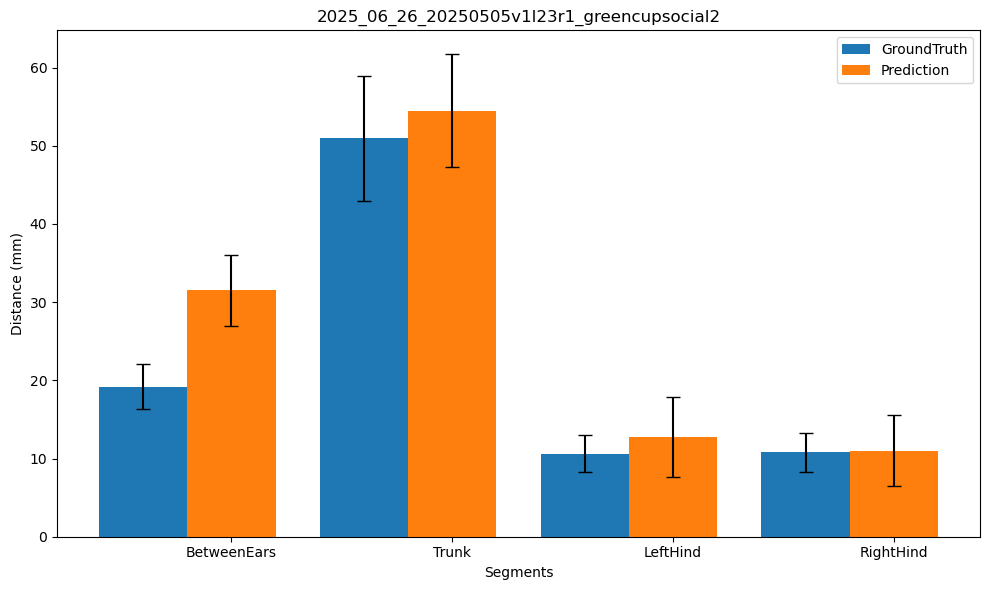

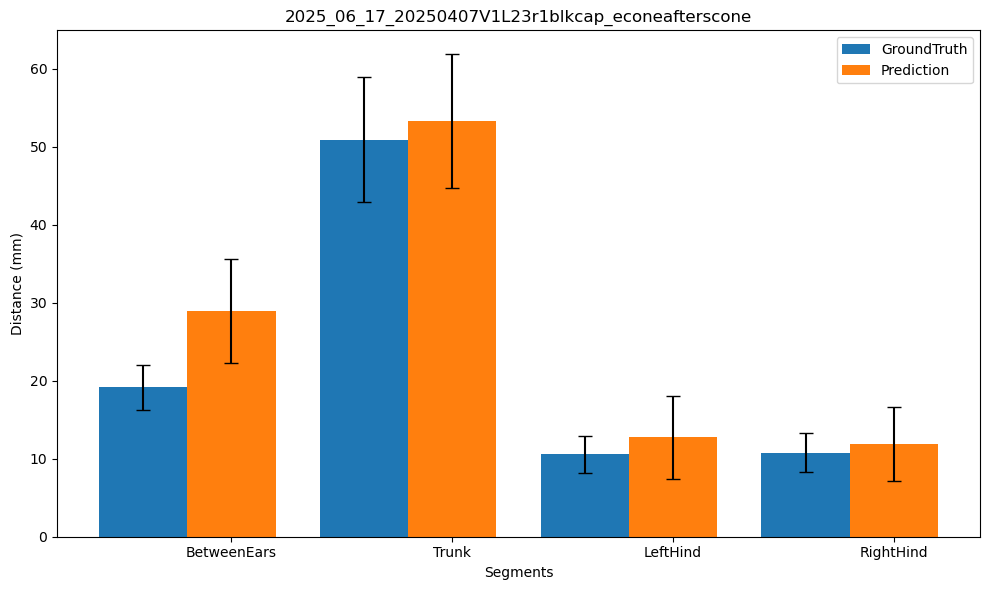

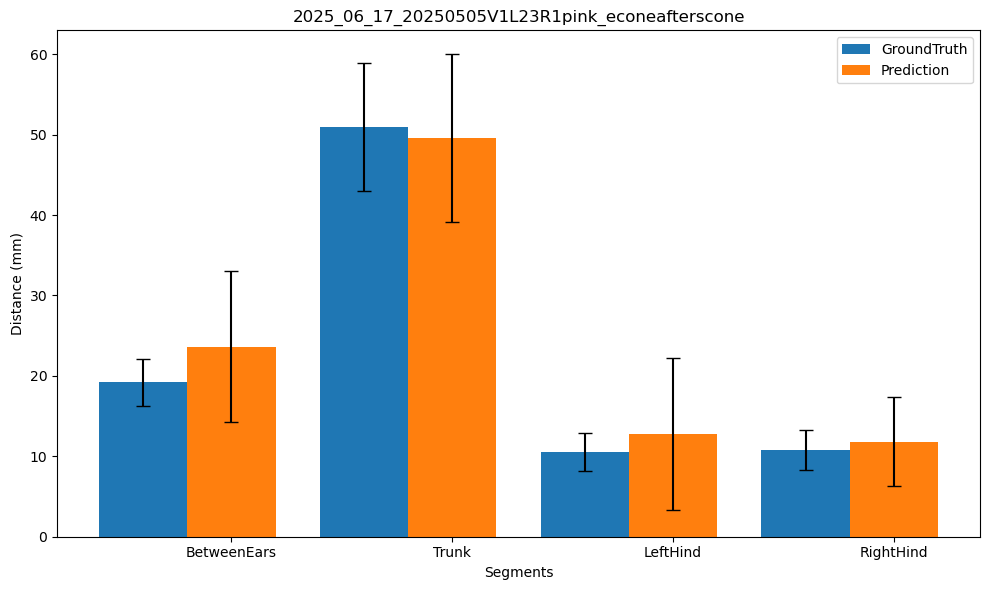

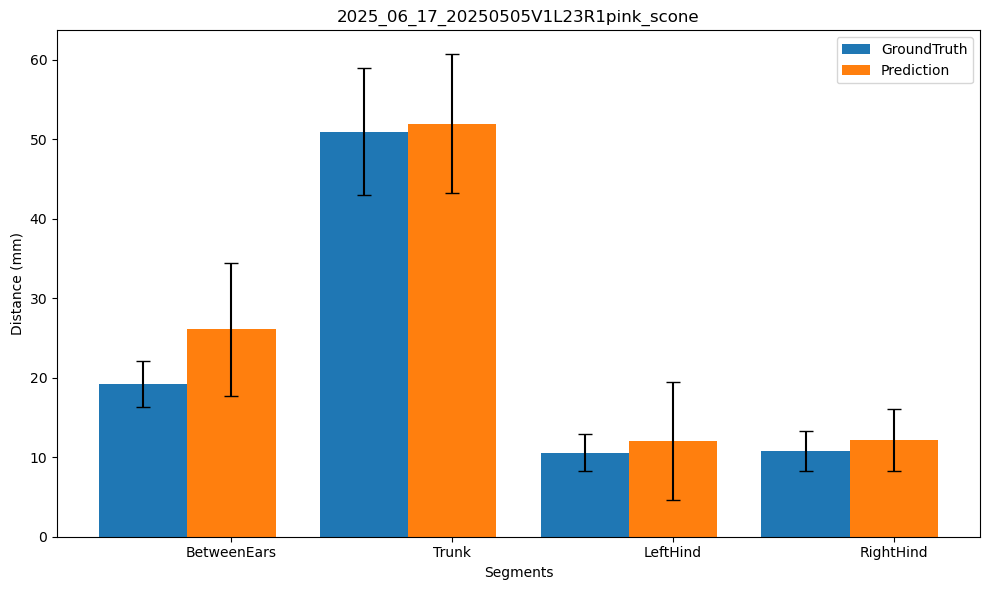

/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_06_26/20250506v1l23l1_clearsocialcup
/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_06_26/20250506v1l23l1_greensocialcup_mini/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_06_26/20250506v1l23l1_greensocialcup

/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_06_26/20250506v1l23l1_greensocialcup2


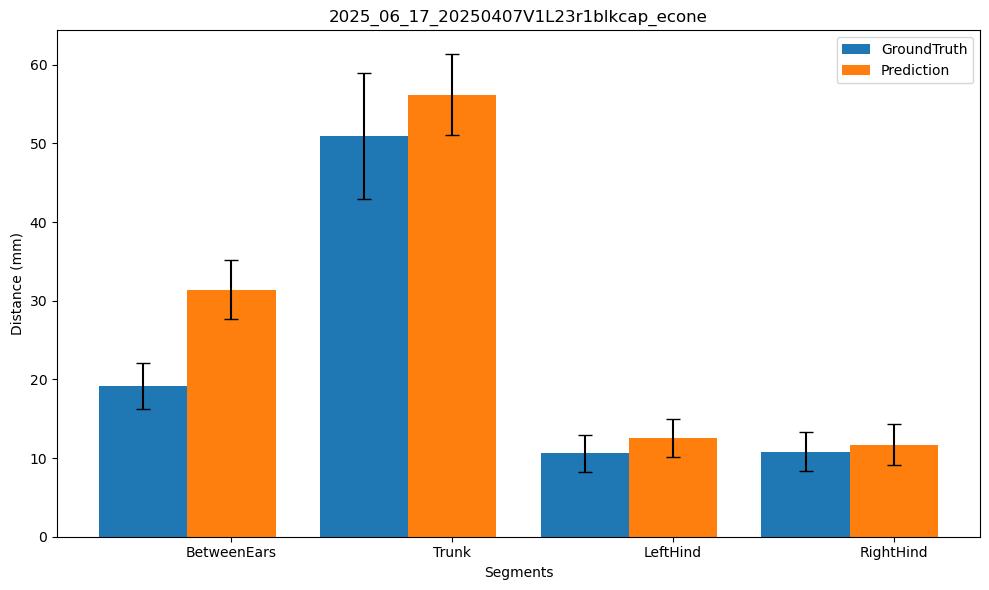

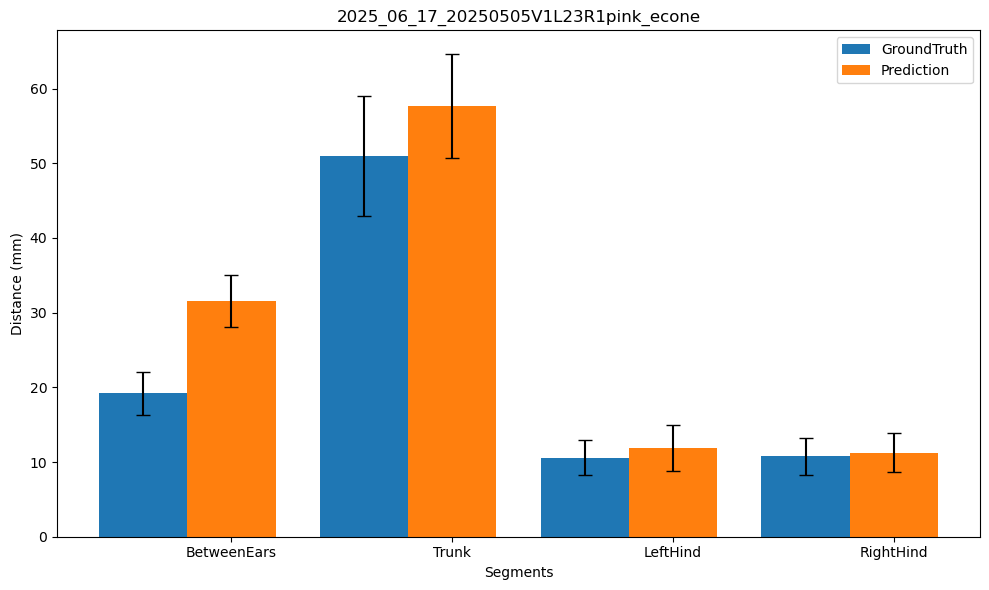

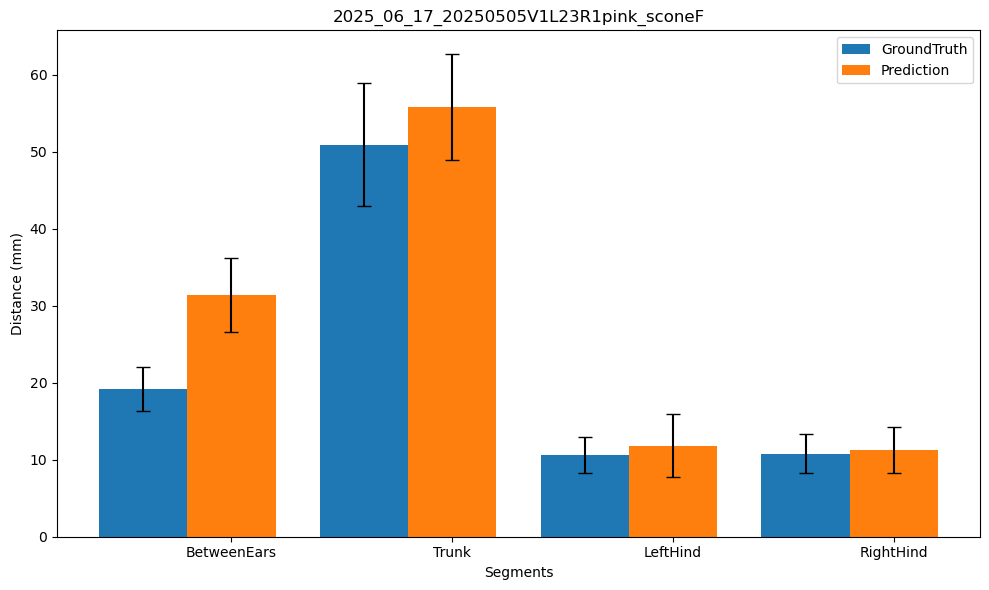

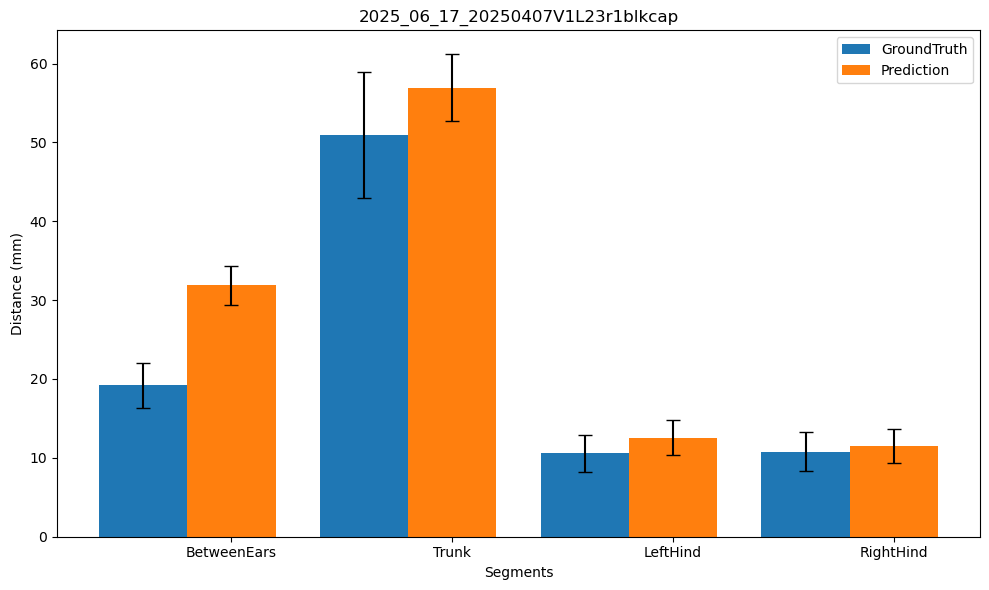

Plot saved as '/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_06_26/20250506v1l23l1_greensocialcup/DANNCE/predict00/vis/2025_06_26_20250506v1l23l1_greensocialcup.jpg'.


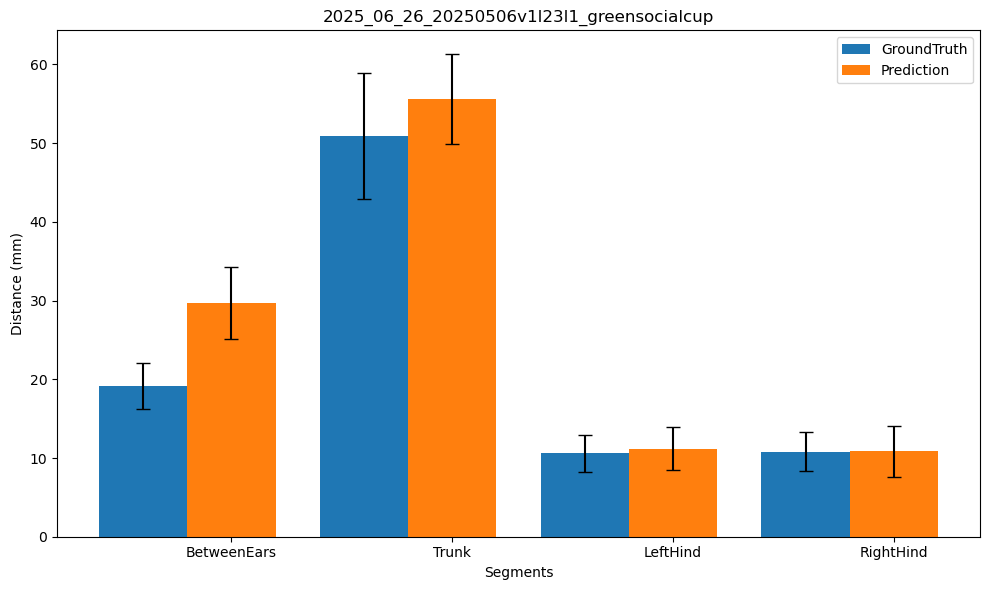

Plot saved as '/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_06_26/20250506v1l23l1_greensocialcup2/DANNCE/predict00/vis/2025_06_26_20250506v1l23l1_greensocialcup2.jpg'.
Plot saved as '/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_06_26/20250506v1l23l1_clearsocialcup/DANNCE/predict00/vis/2025_06_26_20250506v1l23l1_clearsocialcup.jpg'.
Plot saved as '/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_06_26/20250506v1l23l1_greensocialcup_mini/DANNCE/predict00/vis/2025_06_26_20250506v1l23l1_greensocialcup_mini.jpg'.


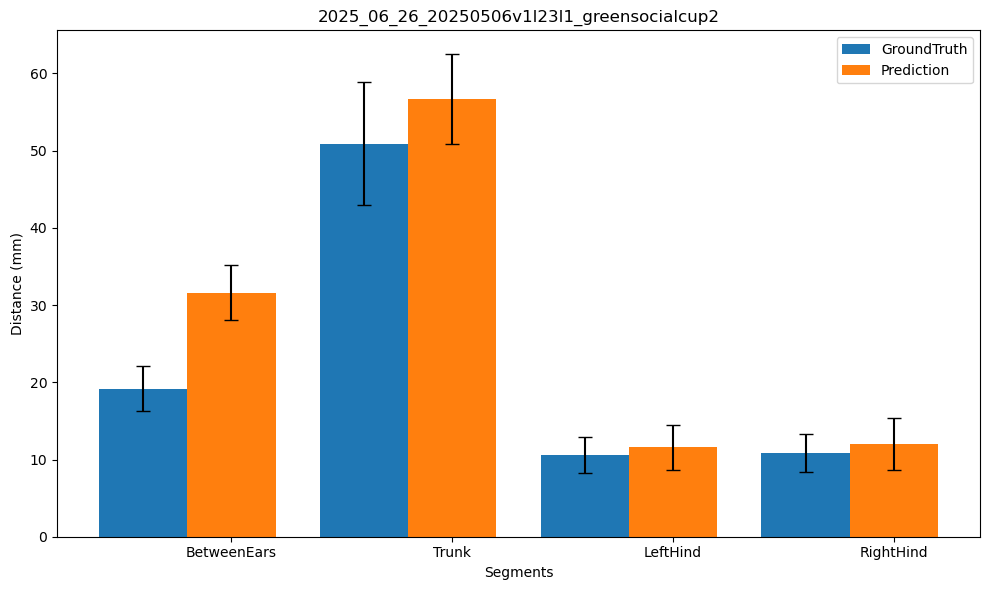

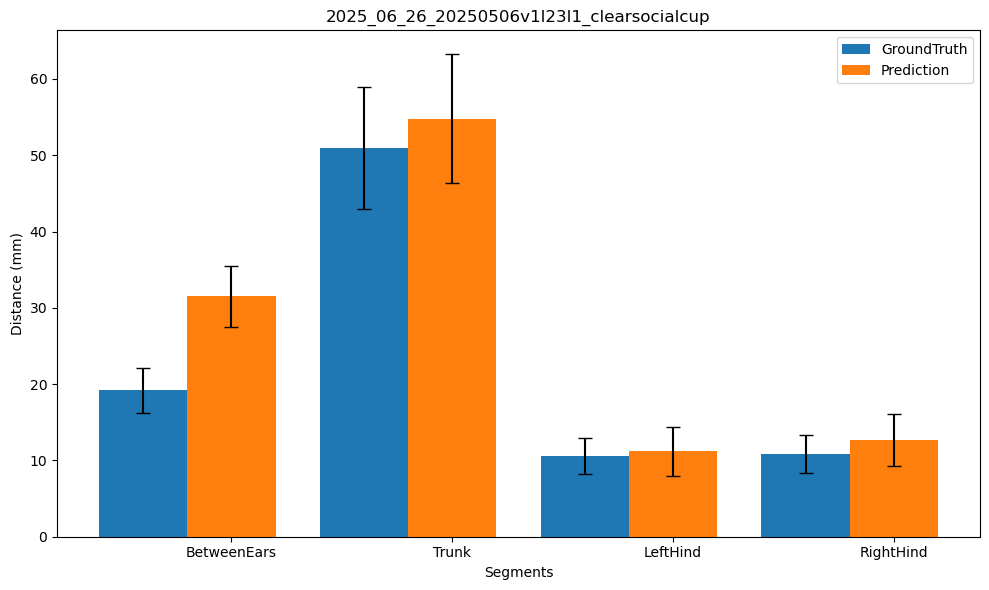

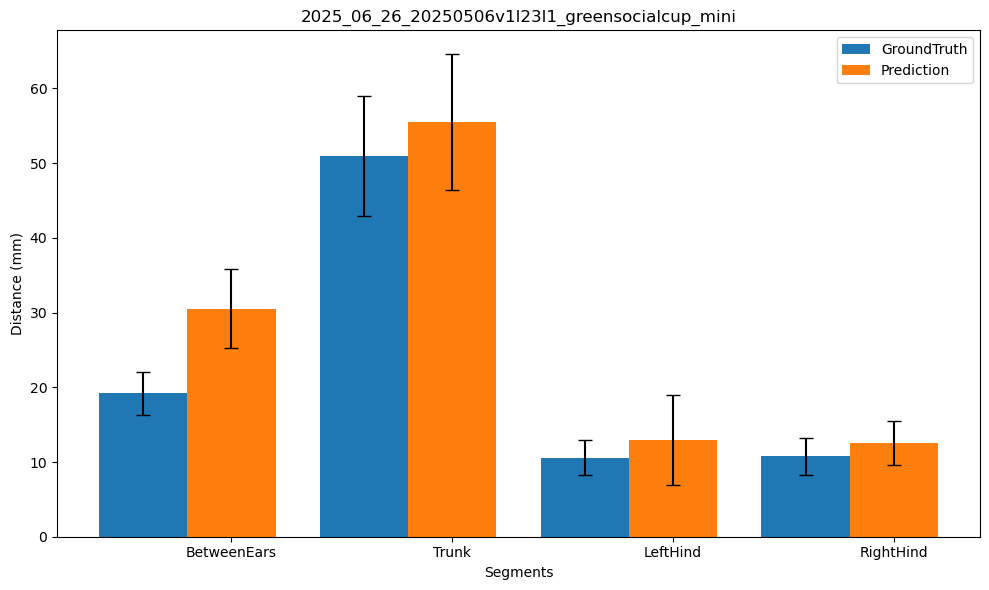

In [11]:
from useful_files.sophie_check_dannce_mir_modif import dannce_valid

for_dannce_vis = for_dannce

records = [
    {
        'date_folder': date_folder.as_py(),  # Convert to string using as_py()
        'rec_file': rec_file.as_py()         # Convert to string using as_py()
    }
    for date_folder, rec_file in zip(for_dannce_vis['date_folder'], for_dannce_vis['rec_file'])
]

# Iterate through the records and process each one sequentially
# for record in records:
#     base_path = f"{base_folder}/{record['date_folder']}/{record['rec_file']}"
#     print(base_path)
#     try:
#         dannce_valid(base_path) #com_folder_name='COM/predict00', perform_jump_indices=True, perform_video_generation=False, perform_generate_com_video=False
#     except Exception as e:
#         print(f"An error occurred while processing {base_path}: {e}")
#         # Skip to the next record if an error occurs
#         continue

#trying for parallel processing again:
from concurrent.futures import ProcessPoolExecutor, as_completed

def process_record(record):
    base_path = f"{base_folder}/{record['date_folder']}/{record['rec_file']}"
    print(base_path)
    try:
        dannce_valid(base_path)
    except Exception as e:
        print(f"An error occurred while processing {base_path}: {e}")
        # Skip to the next record if an error occurs
        pass

with ProcessPoolExecutor() as executor:
    futures = [executor.submit(process_record, record) for record in records]
    for future in as_completed(futures):
        pass  # You can retrieve results or handle exceptions here if needed
